# Imports

In [ ]:
df_esg = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/esg_yearly.csv")

# EDA for ESG data

In [ ]:
print(df_esg.shape)
print(df_esg.info())
df_esg.head()

(2093, 16)
<class 'pandas.DataFrame'>
RangeIndex: 2093 entries, 0 to 2092
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   moodys_bvd_id          2093 non-null   str    
 1   company_name           2093 non-null   str    
 2   risk_level             2093 non-null   str    
 3   sector                 2093 non-null   str    
 4   year                   2093 non-null   int64  
 5   Join_Year              2093 non-null   int64  
 6   esg_overall            2093 non-null   float64
 7   esg_industry_adjusted  2093 non-null   float64
 8   env_score              2093 non-null   float64
 9   env_weight             2093 non-null   float64
 10  social_score           2093 non-null   float64
 11  social_weight          2093 non-null   float64
 12  gov_score              2093 non-null   float64
 13  gov_weight             2093 non-null   float64
 14  industry_min           2093 non-null   float64
 15  indu

,moodys_bvd_id,company_name,risk_level,sector,year,Join_Year,esg_overall,esg_industry_adjusted,env_score,env_weight,social_score,social_weight,gov_score,gov_weight,industry_min,industry_max
0,AE0043368774,Fifth Element Event Management L.L.C,Take caution,Business Services,2023,2024,5.0,5.0,9.0,5.0,6.0,28.0,5.0,67.0,3.0,8.0
1,AT9070096767,Zauner Anlagentechnik GmbH,Go ahead,"Industrial, Electric & Electronic Machinery",2023,2024,3.0,1.0,3.0,33.0,3.0,20.0,5.0,47.0,3.0,7.0
2,AT9070096767,Zauner Anlagentechnik GmbH,Go ahead,"Industrial, Electric & Electronic Machinery",2024,2025,3.0,1.0,3.0,33.0,1.0,20.0,5.0,47.0,3.0,7.0
3,AT9070096767,Zauner Anlagentechnik GmbH,Go ahead,"Industrial, Electric & Electronic Machinery",2025,2026,3.0,1.0,3.0,33.0,1.0,20.0,5.0,47.0,3.0,7.0
4,AT9110192427,Flextronics International Gesellschaft m.b.H.,Do not source,Metals & Metal Products,2023,2024,4.0,1.0,4.0,40.0,4.0,25.0,5.0,35.0,4.0,7.0


In [ ]:
df_esg["esg_position_in_industry_range"] = (
    (df_esg["esg_overall"] - df_esg["industry_min"]) /
    (df_esg["industry_max"] - df_esg["industry_min"])
)

print("\nSummary of ESG position in industry range:")
display(df_esg["esg_position_in_industry_range"].describe())


Summary of ESG position in industry range:


count    2093.000000
mean        0.412765
std         0.250206
min        -0.333333
25%         0.250000
50%         0.400000
75%         0.500000
max         1.333333
Name: esg_position_in_industry_range, dtype: float64

Quick threshold checks for possible labeling logic

In [ ]:
threshold_summary = pd.DataFrame({
    "esg_overall <= 2": [df_esg["esg_overall"].le(2).mean()],
    "esg_overall <= 3": [df_esg["esg_overall"].le(3).mean()],
    "esg_industry_adjusted <= 1": [df_esg["esg_industry_adjusted"].le(1).mean()],
    "esg_industry_adjusted <= 2": [df_esg["esg_industry_adjusted"].le(2).mean()],
    "env_score <= 2": [df_esg["env_score"].le(2).mean()],
    "env_score <= 3": [df_esg["env_score"].le(3).mean()],
    "social_score <= 2": [df_esg["social_score"].le(2).mean()],
    "social_score <= 3": [df_esg["social_score"].le(3).mean()],
    "gov_score <= 4": [df_esg["gov_score"].le(4).mean()],
    "position_in_range <= 0.10": [df_esg["esg_position_in_industry_range"].le(0.10).mean()],
    "position_in_range <= 0.25": [df_esg["esg_position_in_industry_range"].le(0.25).mean()],
}).T.reset_index()

threshold_summary.columns = ["candidate_rule", "share_of_rows"]
display(threshold_summary.sort_values("share_of_rows", ascending=False))

,candidate_rule,share_of_rows
7,social_score <= 3,0.456283
10,position_in_range <= 0.25,0.362637
5,env_score <= 3,0.304826
6,social_score <= 2,0.296226
3,esg_industry_adjusted <= 2,0.273292
4,env_score <= 2,0.182513
1,esg_overall <= 3,0.175346
2,esg_industry_adjusted <= 1,0.154802
9,position_in_range <= 0.10,0.113235
8,gov_score <= 4,0.053034


In [ ]:
display(
    df_esg[
        [
            "company_name",
            "Join_Year",
            "risk_level",
            "sector",
            "esg_overall",
            "esg_industry_adjusted",
            "env_score",
            "social_score",
            "gov_score",
            "industry_min",
            "industry_max",
            "esg_position_in_industry_range"
        ]
    ]
    .sort_values(
        ["esg_overall", "esg_industry_adjusted", "esg_position_in_industry_range"],
        ascending=True
    )
    .head(20)
)

,company_name,Join_Year,risk_level,sector,esg_overall,esg_industry_adjusted,env_score,social_score,gov_score,industry_min,industry_max,esg_position_in_industry_range
442,"Wuxi biologics co., ltd.",2024,Take caution,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,1.0,4.0,3.0,6.0,-0.333333
469,"Beijing doublerise technology co., ltd.",2024,Take caution,Retail,2.0,0.0,3.0,0.0,4.0,3.0,6.0,-0.333333
470,"Beijing doublerise technology co., ltd.",2025,Take caution,Retail,2.0,0.0,4.0,0.0,4.0,3.0,6.0,-0.333333
471,"Beijing doublerise technology co., ltd.",2023,Take caution,Retail,2.0,0.0,3.0,0.0,4.0,3.0,6.0,-0.333333
502,"Nanjing gensript biotechnology co., ltd.",2024,Take caution,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,1.0,4.0,3.0,6.0,-0.333333
503,"Nanjing gensript biotechnology co., ltd.",2023,Take caution,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,1.0,4.0,3.0,6.0,-0.333333
1001,Evapharma FOR Pharmaceutical Industries,2024,Do not source,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,2.0,4.0,2.0,6.0,0.000000
1002,Evapharma FOR Pharmaceutical Industries,2025,Do not source,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,0.0,1.0,4.0,2.0,6.0,0.000000
1485,"Korea Engineering Plastics Co.,Ltd",2025,Go ahead,"Chemicals, Petroleum, Rubber & Plastic",2.0,0.0,2.0,0.0,4.0,2.0,6.0,0.000000
73,Sopharma AD,2024,Go ahead,"Chemicals, Petroleum, Rubber & Plastic",2.0,1.0,2.0,2.0,3.0,2.0,6.0,0.000000


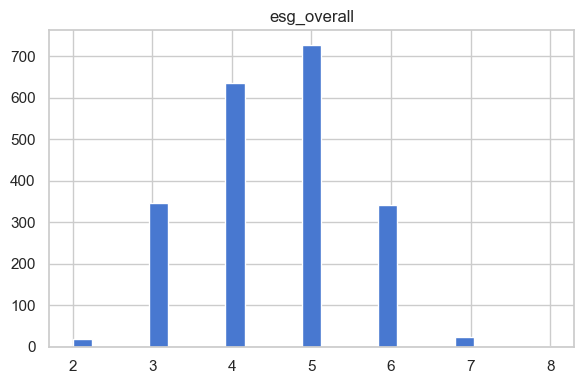

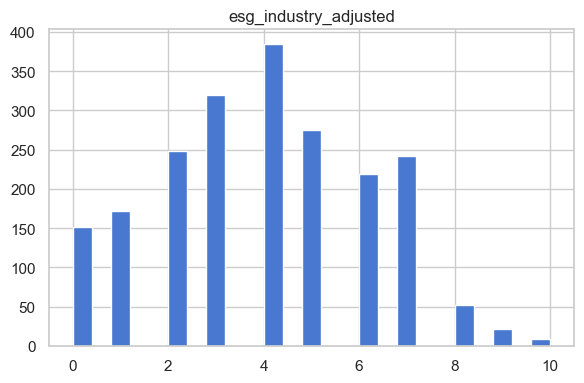

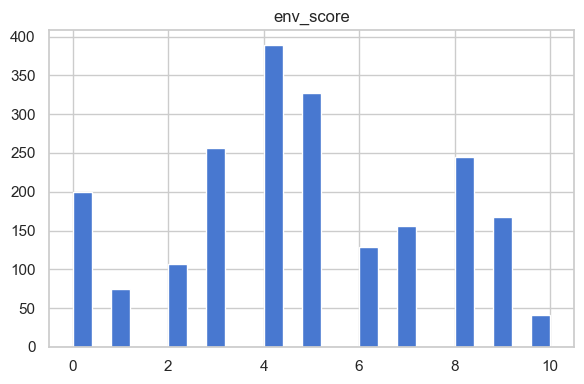

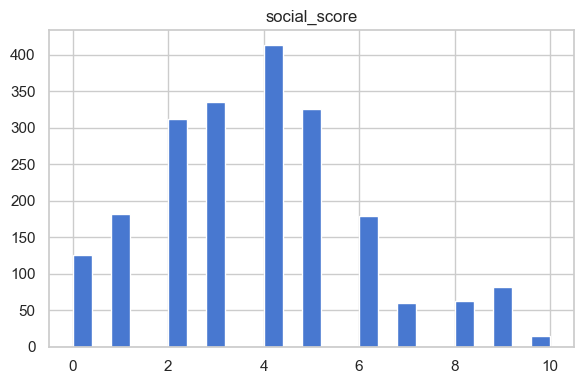

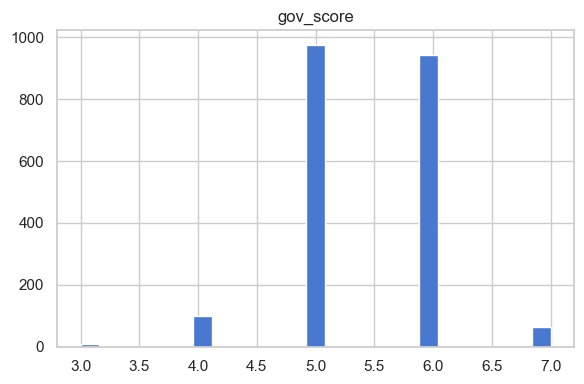

In [ ]:
# ------------------------------------------------------------
# 5. Simple plots
# ------------------------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(df_esg["esg_overall"], bins=25)
plt.title("esg_overall")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_esg["esg_industry_adjusted"], bins=25)
plt.title("esg_industry_adjusted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_esg["env_score"], bins=25)
plt.title("env_score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_esg["social_score"], bins=25)
plt.title("social_score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df_esg["gov_score"], bins=25)
plt.title("gov_score")
plt.tight_layout()
plt.show()